In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [2]:
ds = xr.open_zarr("Simulation_Satellite_kN_0.001.zarr").dropna(dim='obs', how='all')

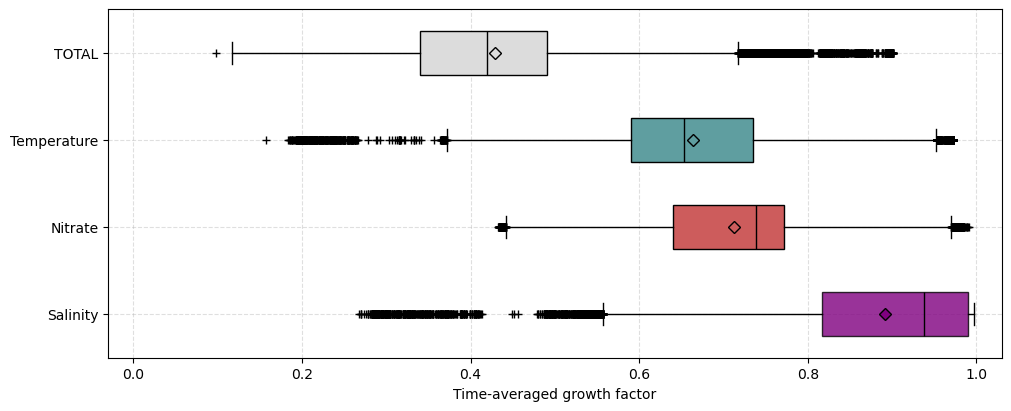

In [3]:
plt.figure(figsize=(10, 4), constrained_layout=True)

#Calculating mean over time of limitation values
timemean_lim_sal = ds['lim_salinity'].mean(dim='obs')
timemean_lim_temp = ds['lim_temp'].mean(dim='obs')
timemean_lim_no3 = ds['lim_no3'].mean(dim='obs')
timemean_lim_tot = ds['limitation'].mean(dim='obs')

boxplot_list = [timemean_lim_sal, timemean_lim_no3, timemean_lim_temp, timemean_lim_tot]

limitation_names = ['Salinity', 'Nitrate', 'Temperature', '''TOTAL''']
colors = ['purple' , 'indianred', 'cadetblue', 'gainsboro']
alphas = [0.8, 1, 1, 1]

#Boxplots with different colors
for i, data in enumerate(boxplot_list):
    plt.boxplot(
        data,
        positions=[i],
        widths=0.5,
        patch_artist=True,
        orientation='horizontal',
        boxprops=dict(facecolor=colors[i], alpha=alphas[i]),
        medianprops=dict(color='black'),
        showmeans=True,
        meanprops = dict(marker='D',markeredgecolor='black', markerfacecolor=colors[i]),
        sym='+',
    )

plt.yticks(range(4) , limitation_names, rotation=0)
plt.xlabel('Time-averaged growth factor')
plt.xlim(-0.03, 1.03)
plt.grid( linestyle='--', alpha=0.4)
plt.savefig('Figure4.pdf', bbox_inches='tight', dpi=300)
plt.show()